In [1]:
# 04_quantum_circuit_builder.py
"""
FlagQuantum Tutorial - Lesson 4: Building Quantum Circuits
Goal: Learn to build reusable circuits using GeneralEncoder and VariationalLayer

Topics covered:
1. Data encoding with GeneralEncoder
2. Building trainable variational layers
3. Combining encoders and variational layers to form quantum neural networks
4. Building common quantum circuits
"""
import flagquantum as fq
from flagquantum.encoding import GeneralEncoder, angle_encoder, create_encoding_circuit

In [2]:
import math

import torch


def example_1_custom_encoder():
    """Example 1: Custom encoder"""
    print("=" * 60)
    print("4.1 Custom Encoder (GeneralEncoder)")
    print("=" * 60)

    # Define encoding circuit
    func_list = [
        {"func": "ry", "wires": [0], "input_idx": 0},  # feature 0 → qubit 0
        {"func": "ry", "wires": [1], "input_idx": 1},  # feature 1 → qubit 1
        {"func": "cx", "wires": [0, 1]},                # Non-parameterized entanglement gate
        {"func": "rz", "wires": [0], "input_idx": 0},   # Encode again
    ]

    encoder = GeneralEncoder(func_list)
    print(f"Encoder: {encoder}")
    print(f"Number of gates: {len(encoder._gate_types)}")

    # Create data and device
    batch_size = 2
    n_features = 2
    qdev = fq.DistributedQuantumDevice(n_wires=2, bsz=batch_size, device="cpu")
    x = torch.randn(batch_size, n_features)

    print(f"\nInput data: {x}")

    # Apply encoding
    encoder(qdev, x)

    # Check results
    states = torch.view_as_complex(qdev.states)
    print(f"Encoded state shape: {states.shape}")


def example_2_factory_encoder():
    """Example 2: Create encoder using factory function"""
    print("\n" + "=" * 60)
    print("4.2 Factory Function for Encoder Creation")
    print("=" * 60)

    # Angle encoding
    encoder_angle = create_encoding_circuit("angle", n_qubits=4, n_features=4)
    print(f"Angle encoder: {encoder_angle}")

    # Basis encoding
    encoder_basis = create_encoding_circuit("basis", n_qubits=4, n_features=4)
    print(f"Basis encoder: {encoder_basis}")

    # Use angle encoder
    qdev = fq.DistributedQuantumDevice(n_wires=4, bsz=1, device="cpu")
    x = torch.tensor([[0.5, 0.3, 0.8, 0.2]])

    encoder_angle(qdev, x)

    states = torch.view_as_complex(qdev.states)
    print(f"\nState after angle encoding: {states.flatten()[:4]}...")


def example_3_convenience_encoder():
    """Example 3: Convenience encoding functions"""
    print("\n" + "=" * 60)
    print("4.3 Convenience Encoding Functions")
    print("=" * 60)

    qdev = fq.DistributedQuantumDevice(n_wires=4, bsz=2, device="cpu")
    x = torch.randn(2, 4)  # 2 batches, 4 features

    print(f"Input data shape: {x.shape}")

    # Angle encoding
    angle_encoder(qdev, x, wires=[0, 1, 2, 3], rotation="ry")

    states = torch.view_as_complex(qdev.states)
    print(f"State shape after angle encoding: {states.shape}")
    print(f"State norm: {torch.norm(states).item():.4f}")


def circuit_bell_state(qdev):
    """Bell state circuit"""
    fq.H(wires=[0])(qdev)
    fq.CNOT(wires=[0, 1])(qdev)


def circuit_ghz_state(qdev, n_qubits=3):
    """GHZ state circuit"""
    fq.H(wires=[0])(qdev)
    for i in range(n_qubits - 1):
        fq.CNOT(wires=[i, i + 1])(qdev)


def circuit_qft2(qdev):
    """2-qubit QFT"""
    fq.H(wires=[0])(qdev)
    fq.CPHASE(wires=[1, 0], params=torch.tensor([math.pi / 2]))(qdev)
    fq.H(wires=[1])(qdev)
    # Swap outputs
    fq.SWAP(wires=[0, 1])(qdev)


def example_4_standard_circuits():
    """Example 5: Standard quantum circuits"""
    print("\n" + "=" * 60)
    print("4.4 Standard Quantum Circuits")
    print("=" * 60)

    # Bell state
    qdev = fq.DistributedQuantumDevice(n_wires=2, bsz=1, device="cpu")
    circuit_bell_state(qdev)
    states = torch.view_as_complex(qdev.states)
    print(f"Bell state: {states.flatten()}")
    print(f"Probabilities: {torch.abs(states)**2}")

    # GHZ state
    qdev = fq.DistributedQuantumDevice(n_wires=3, bsz=1, device="cpu")
    circuit_ghz_state(qdev, n_qubits=3)
    states = torch.view_as_complex(qdev.states)
    probs = torch.abs(states) ** 2
    print("\nGHZ state: positions with non-zero probability")
    for i, p in enumerate(probs.flatten()):
        if p > 0.1:
            binary = format(i, '03b')
            print(f"  |{binary}⟩: {p:.3f}")

In [3]:
example_1_custom_encoder()

4.1 Custom Encoder (GeneralEncoder)
Encoder: GeneralEncoder(gates=4)
Number of gates: 4

Input data: tensor([[ 1.3925, -1.9457],
        [-0.7235,  0.5527]])
Encoded state shape: torch.Size([2, 2, 2])


In [4]:
example_2_factory_encoder()


4.2 Factory Function for Encoder Creation
Angle encoder: GeneralEncoder(gates=4)
Basis encoder: GeneralEncoder(gates=4)

State after angle encoding: tensor([0.8780+0.j, 0.0881+0.j, 0.3712+0.j, 0.0372+0.j])...


In [5]:
example_3_convenience_encoder()


4.3 Convenience Encoding Functions
Input data shape: torch.Size([2, 4])
State shape after angle encoding: torch.Size([2, 2, 2, 2, 2])
State norm: 1.4142


In [6]:
example_4_standard_circuits()


4.4 Standard Quantum Circuits
Bell state: tensor([0.7071+0.j, 0.0000+0.j, 0.0000+0.j, 0.7071+0.j])
Probabilities: tensor([[[0.5000, 0.0000],
         [0.0000, 0.5000]]])

GHZ state: positions with non-zero probability
  |000⟩: 0.500
  |111⟩: 0.500


In [7]:
# A quantum circuit is constructed as a special Python function, a quantum circuit function, or quantum function in short. For example:

nq=4
bsz=2
world_sz=1

# Defining a device
# The n_wires argument can be an integer that defines the number of wires that you can address by consecutive integer labels 0, 1, 2, ....
qdev = fq.DistributedQuantumDevice(n_wires=nq, bsz=bsz, world_sz=world_sz, device="cpu",record_op=True)

In [8]:
def my_comprehensive_quantum_function(qdev):
    """Test long circuit with automatic line wrapping - includes all supported gate types
    Args:
        qdev: Quantum device
    """
    # ========== Layer 1: Basic single-qubit gates ==========
    fq.I(wires=[0])(qdev)                     # Identity gate
    fq.X(wires=[1])(qdev)                     # Pauli-X
    fq.Y(wires=[2])(qdev)                     # Pauli-Y
    fq.Z(wires=[3])(qdev)                     # Pauli-Z

    # ========== Layer 2: Clifford gates ==========
    fq.H(wires=[0])(qdev)                     # Hadamard
    fq.S(wires=[1])(qdev)                     # S gate
    fq.SDG(wires=[2])(qdev)                   # S† gate
    fq.T(wires=[3])(qdev)                     # T gate
    fq.TDG(wires=[0])(qdev)                   # T† gate

    # ========== Layer 3: SX gates (new) ==========
    fq.SX(wires=[1])(qdev)                    # SX gate (√X)
    fq.SXDG(wires=[2])(qdev)                  # SX† gate

    # ========== Layer 4: Rotation gates (parameterized) ==========
    fq.RX(wires=[0])(qdev)          # RX rotation
    fq.RY(wires=[1])(qdev)          # RY rotation
    fq.RZ(wires=[2])(qdev)          # RZ rotation
    fq.RX(wires=[3])(qdev)          # RX rotation

    # ========== Layer 5: Phase gates (new) ==========
    fq.P(wires=[0])(qdev)      # Phase gate P(θ)
    fq.PHASE(wires=[1])(qdev)  # Phase gate alias

    # ========== Layer 6: CNOT gate family ==========
    fq.CX(wires=[0, 1])(qdev)                 # CNOT (controlled-NOT)
    fq.CY(wires=[2, 3])(qdev)                 # CY (controlled-Y)
    fq.CZ(wires=[0, 2])(qdev)                 # CZ (controlled-Z)
    fq.CPHASE(wires=[3, 1])(qdev)  # CPhase gate

    # ========== Layer 7: Controlled rotation gates (new) ==========
    fq.CRX(wires=[0, 1])(qdev)      # CRX(θ)
    fq.CRY(wires=[2, 3])(qdev)      # CRY(θ)
    fq.CRZ(wires=[0, 2])(qdev)      # CRZ(θ)

    # ========== Layer 8: SWAP gates ==========
    fq.SWAP(wires=[1, 3])(qdev)               # SWAP gate
    fq.CX(wires=[3, 0])(qdev)                 # Additional CNOT

    # ========== Layer 9: Ising gates (new) ==========
    fq.RXX(wires=[0, 1])(qdev)  # Ising XX gate
    fq.RYY(wires=[2, 3])(qdev)  # Ising YY gate
    fq.RZZ(wires=[0, 2])(qdev)  # Ising ZZ gate

    # ========== Layer 10: More rotation gates ==========
    fq.RY(wires=[0])(qdev)
    fq.RZ(wires=[1])(qdev)
    fq.RX(wires=[2])(qdev)
    fq.RY(wires=[3])(qdev)

    # ========== Layer 11: Three-qubit gates ==========
    fq.CCX(wires=[0, 1, 2])(qdev)             # Toffoli (CCX)
    fq.CSWAP(wires=[0, 1, 3])(qdev)           # Fredkin (CSWAP)

    # ========== Measure all qubits ==========
    return fq.measure_allZ(qdev)

In [9]:
my_comprehensive_quantum_function(qdev)

tensor([[-0.0282,  0.0417,  0.3742,  0.1356],
        [-0.0131,  0.0119,  0.4668, -0.0215]], grad_fn=<UnsafeViewBackward0>)

0: |0⟩ ───I────H─────T†────────────RX(-0.376)────P(-0.493)───╭●──╭●───────────────╭●────────── ···
1: |0⟩ ───X────S─────SX────────────RY(-0.129)────P(0.105)────╰X──│───╭●───────────╰CRX(0.004)─ ···
2: |0⟩ ───Y────S†────SX†───────────RZ(-0.147)───╭●───────────────╰Z──│────────────╭●────────── ···
3: |0⟩ ───Z────T─────RX(-0.391)─────────────────╰Y───────────────────╰CP(-0.255)──╰CRY(-0.399) ···

0: ··· ──╭●──────────────╭●──╭RXX(0.429)──╭RZZ(0.115)────RY(-0.203)───╭●──╭●───┤  <Z>
1: ··· ──│────────────╳──│───╰RXX(0.429)──├RZZ(0.115)────RZ(0.432)────├●──│────┤  <Z>
2: ··· ──╰CRZ(0.027)──│──│───╭RYY(0.429)──╰RZZ(0.115)────RX(0.297)────╰X──├╳───┤  <Z>
3: ··· ───────────────╳──╰X──╰RYY(0.429)───RY(-0.207)─────────────────────╰╳───┤  <Z>


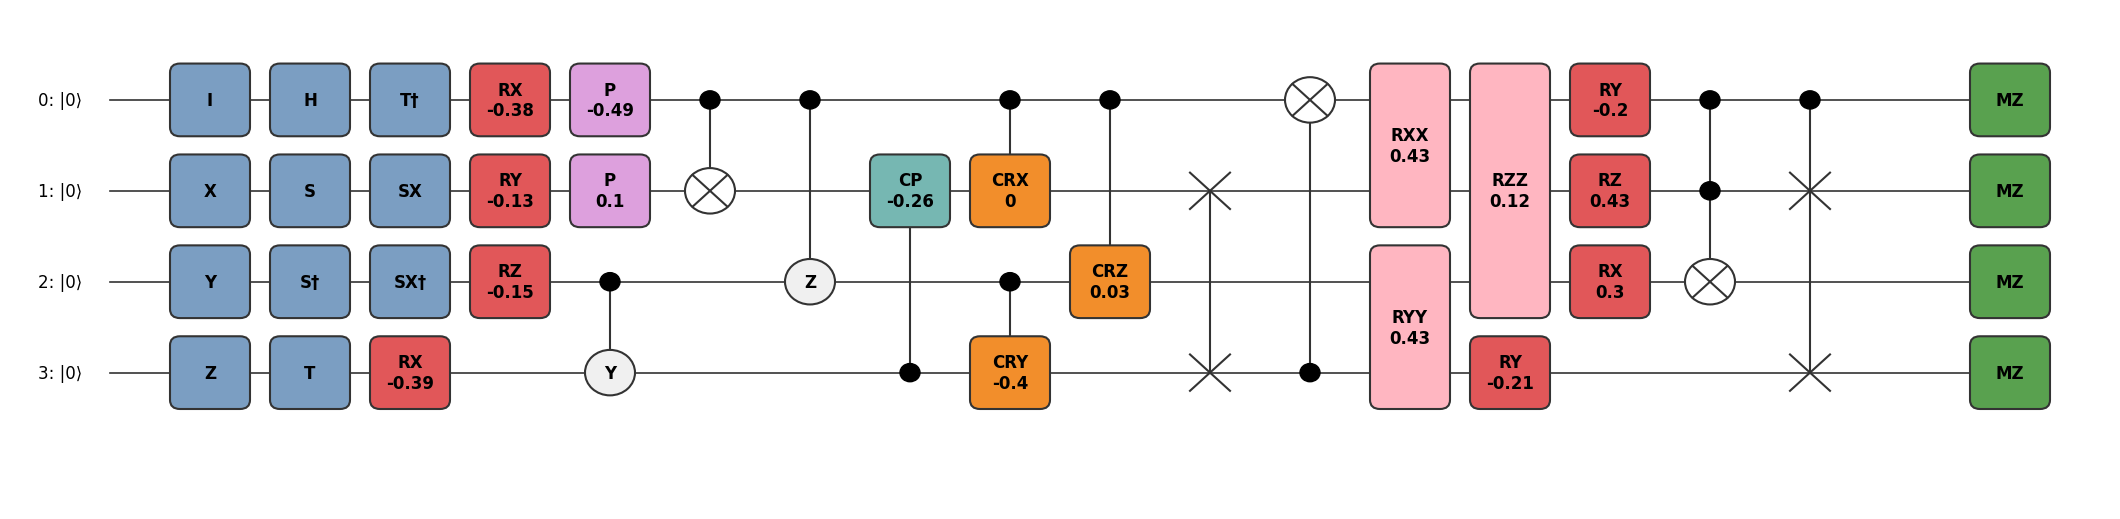

In [10]:
# Text mode (default)
print(fq.draw(qdev, format="text", decimals=3, show_all_wires=True, show_initial_state=True))

# Matplotlib mode
fig, ax = fq.draw(qdev, show_initial_state=True, format="mpl", style="flagquantum")